In [29]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [30]:
computer_times = [16,8,35,17,13,15,15,5,16,25,20,20,12,10]


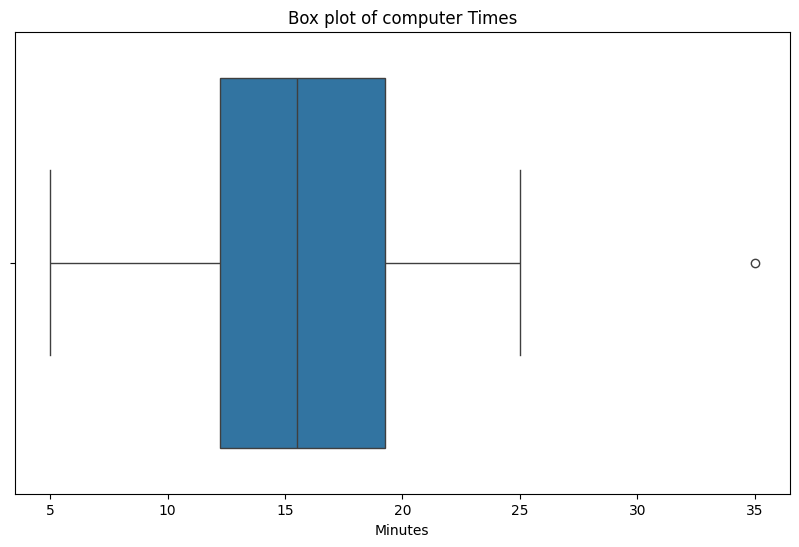

In [31]:
plt.figure(figsize=(10,6))
sns.boxplot(data=computer_times, orient="h")
plt.title("Box plot of computer Times")
plt.xlabel("Minutes")
plt.show()

In [32]:
import numpy as np
q1 = np.percentile(computer_times,25)
q3 = np.percentile(computer_times,75)

print("q1 = ",q1,"  ","q3 =",q3)

iqr = q3-q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

print("iqr = ",iqr,"  lower_bound = ",lower_bound,"  upper_bound =",upper_bound)

outliers = []
for x in computer_times:
    if x< lower_bound or x > upper_bound:
        outliers.append(x)
print("Outliers are =",outliers)


q1 =  12.25    q3 = 19.25
iqr =  7.0   lower_bound =  1.75   upper_bound = 29.75
Outliers are = [35]


In [33]:
data = [10,20,30,40,50]
p90 = np.percentile(data,90)
print(p90)

46.0


In [34]:
from scipy.stats import percentileofscore

data = [10, 20, 30, 40, 50]   # Example dataset
percentile = percentileofscore(data, 40)
print(percentile)


80.0


In [69]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df = pd.read_csv("billionaires.csv")
finalworth = df["finalWorth"]
finalworth.head()

0    211000
1    180000
2    114000
3    107000
4    106000
Name: finalWorth, dtype: int64

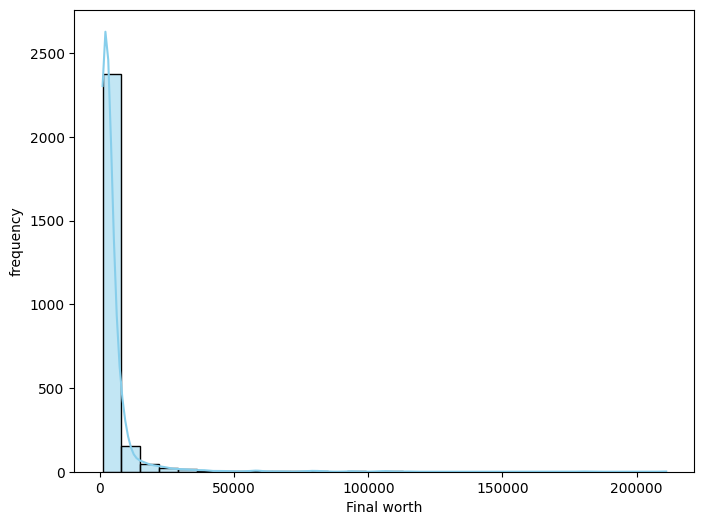

In [71]:
plt.figure(figsize=(8,6))
sns.histplot(finalworth, kde=True, color="skyblue",bins=30)
plt.xlabel("Final worth")
plt.ylabel("frequency")
plt.show()

#kde - kernel Density Estimation Provides a smooth curve over descerete data points

In [72]:
#skewness , kurtosis - billionaries dataset
df = pd.read_csv('billionaires.csv')
finalworth = df["finalWorth"]



In [73]:
mean_finalworth = finalworth.mean()
median_finalworth = finalworth.median()
skewness_finalworth = finalworth.skew()
kurtosis_finalworth = finalworth.kurt()
print("mean_finalworth = ",mean_finalworth," median_finalworth = ",median_finalworth, " skewness_finalworth = ",skewness_finalworth," kurtosis_finalworth = ",kurtosis_finalworth)

mean_finalworth =  4623.787878787879  median_finalworth =  2300.0  skewness_finalworth =  10.012367321086751  kurtosis_finalworth =  145.07368067526582


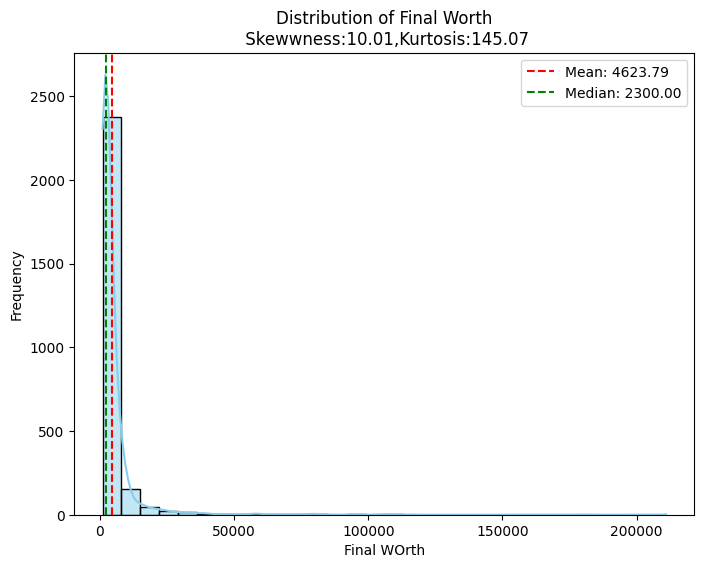

In [74]:
plt.figure(figsize=(8,6))
sns.histplot(finalworth, kde=True, color="skyblue",bins=30)
plt.axvline(mean_finalworth, color="red",linestyle="--",label=f'Mean: {mean_finalworth:.2f}')
plt.axvline(median_finalworth, color="green",linestyle="--",label=f'Median: {median_finalworth:.2f}')
plt.title(f"Distribution of Final Worth\n Skewwness:{skewness_finalworth:.2f},Kurtosis:{kurtosis_finalworth:.2f}")
plt.xlabel("Final WOrth")
plt.ylabel("Frequency")
plt.legend()
plt.show()


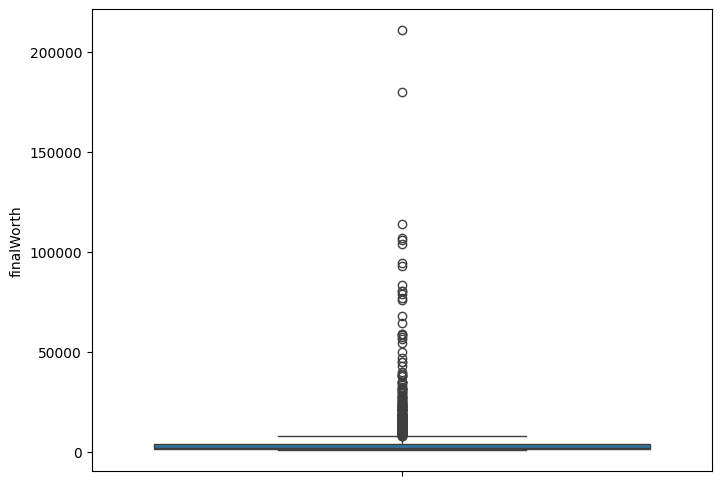

In [75]:
plt.figure(figsize=(8,6))
sns.boxplot(finalworth)
plt.show()

In [78]:
q1 = df["finalWorth"].quantile(0.25)
q3= df["finalWorth"].quantile(0.75)

IQR = q3-q1
lower_fence = q1-(3*IQR)
upper_fence = q3+(3*IQR)

df["is_extreme_outliers"] = (df["finalWorth"]> upper_fence) | (df["finalWorth"]< lower_fence)
print(df["is_extreme_outliers"])

0        True
1        True
2        True
3        True
4        True
        ...  
2635    False
2636    False
2637    False
2638    False
2639    False
Name: is_extreme_outliers, Length: 2640, dtype: bool


In [79]:
num_extreme_outliers = df["is_extreme_outliers"].sum()
print(num_extreme_outliers)

140


In [80]:
df_new = df[df["is_extreme_outliers"]==False].copy()
finalworth = df_new["finalWorth"]
print(finalworth)
mean_finalworth = finalworth.mean()
median_finalworth = finalworth.median()
skewness_finalworth = finalworth.skew()
kurtosis_finalworth = finalworth.kurt()
print("mean_finalworth = ",mean_finalworth," median_finalworth = ",median_finalworth, " skewness_finalworth = ",skewness_finalworth," kurtosis_finalworth = ",kurtosis_finalworth)

140     12300
141     12200
142     12200
143     12100
144     12000
        ...  
2635     1000
2636     1000
2637     1000
2638     1000
2639     1000
Name: finalWorth, Length: 2500, dtype: int64
mean_finalworth =  3035.68  median_finalworth =  2200.0  skewness_finalworth =  1.6646313461296731  kurtosis_finalworth =  2.4284061542640627


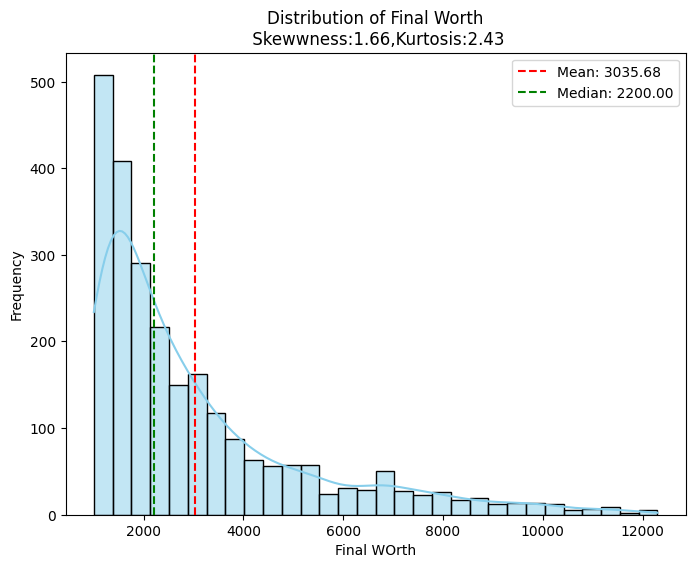

In [81]:
plt.figure(figsize=(8,6))
sns.histplot(finalworth, kde=True, color="skyblue",bins=30)
plt.axvline(mean_finalworth, color="red",linestyle="--",label=f'Mean: {mean_finalworth:.2f}')
plt.axvline(median_finalworth, color="green",linestyle="--",label=f'Median: {median_finalworth:.2f}')
plt.title(f"Distribution of Final Worth\n Skewwness:{skewness_finalworth:.2f},Kurtosis:{kurtosis_finalworth:.2f}")
plt.xlabel("Final WOrth")
plt.ylabel("Frequency")
plt.legend()
plt.show()


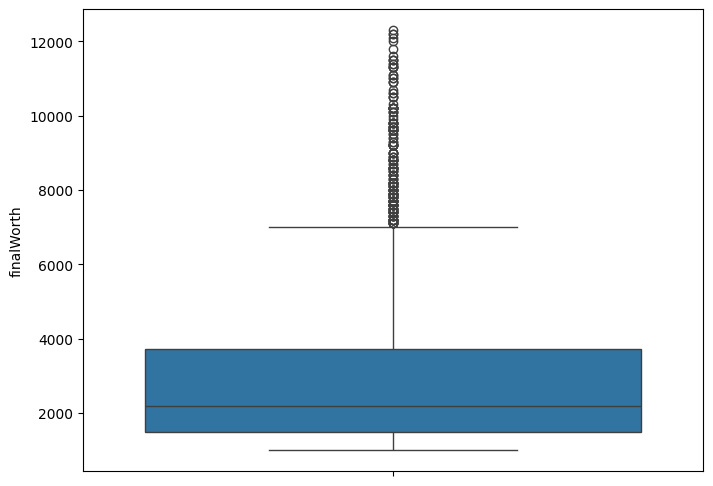

In [82]:
plt.figure(figsize=(8,6))
sns.boxplot(finalworth)
plt.show()

In [84]:
group1_name = 'Fashion & Retail'
group2_name = 'Technology'

group1 = df[df["category"]==group1_name]["finalWorth"]
group2 = df[df["category"]==group2_name]["finalWorth"]

cov_group1 = group1.std()/group1.mean() * 100
cov_group2 = group2.std()/group2.mean() * 100

print(cov_group1,cov_group2)

256.5446922558117 234.77001730968888


In [67]:
df = pd.read_csv('tips.csv')
df

,total_bill,tip,gender,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3.560330e+15,Sun2959
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4.478070e+15,Sun4608
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6.011810e+15,Sun4458
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4.676140e+15,Sun5260
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4.832730e+15,Sun2251
...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,9.68,Michael Avila,5.296070e+15,Sat2657
240,27.18,2.00,Female,Yes,Sat,Dinner,2,13.59,Monica Sanders,3.506810e+15,Sat1766
241,22.67,2.00,Male,Yes,Sat,Dinner,2,11.34,Keith Wong,6.011890e+15,Sat3880
242,17.82,1.75,Male,No,Sat,Dinner,2,8.91,Dennis Dixon,4.375220e+12,Sat17


In [21]:
tip = df["tip"]
tip

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64

In [22]:
mean = tip.mean()
median = tip.median()
skew = tip.skew()
kurt = tip.kurt()

print(mean,median,skew,kurt)

2.99827868852459 2.9 1.4654510370979401 3.648375873352852
